# Notebook 3: Classification Evaluation + Unsupervised Customer Clustering
 
- Task 3.4: Deep performance analysis with confusion matrices, per-class metrics, and business risk evaluation  
- Task 3.5: K-Means customer behavior clustering with business interpretation

---

## 3.1 Setup & Load Artifacts

This notebook depends on artifacts from **Notebooks 1 and 2**:
-  — the preprocessed feature matrix
- ,  — label encoders for decoding predictions
- ,  — trained classifiers
- ,  — held-out test data for evaluation


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, precision_recall_fscore_support,
                              accuracy_score)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded!")

Libraries loaded!


In [4]:
# Load artifacts from Notebooks 1 and 2
df                  = pd.read_csv('../artifacts/cleaned_data.csv')
le_delivery         = joblib.load('../artifacts/le_delivery.joblib')
le_segment          = joblib.load('../artifacts/le_segment.joblib')
best_delivery_model = joblib.load('../artifacts/best_delivery_model.joblib')
best_segment_model  = joblib.load('../artifacts/best_segment_model.joblib')

X_test_s = np.load('../artifacts/X_test_s.npy')
y_test_s = np.load('../artifacts/y_test_s.npy')
X_test_d = np.load('../artifacts/X_test_d.npy')
y_test_d = np.load('../artifacts/y_test_d.npy')

y_pred_d = best_delivery_model.predict(X_test_d)
y_pred_s = best_segment_model.predict(X_test_s)

print("All artifacts loaded successfully!")

All artifacts loaded successfully!


---
# PART A — CLASSIFICATION EVALUATION (Task 3.4)

The confusion matrix stands as the primary evaluation metric which assesses multi-class classification performance. The system provides two types of information because it displays both total correct results and the specific areas where the system makes errors. The system runs three tests to determine which classes the system confuses with other classes. The testing process checks whether the system exhibits a preference for the dominant class. The testing process checks whether the system treats Returned and VIP classes as unimportant.

---
## 3.2 Confusion Matrix — Delivery Status

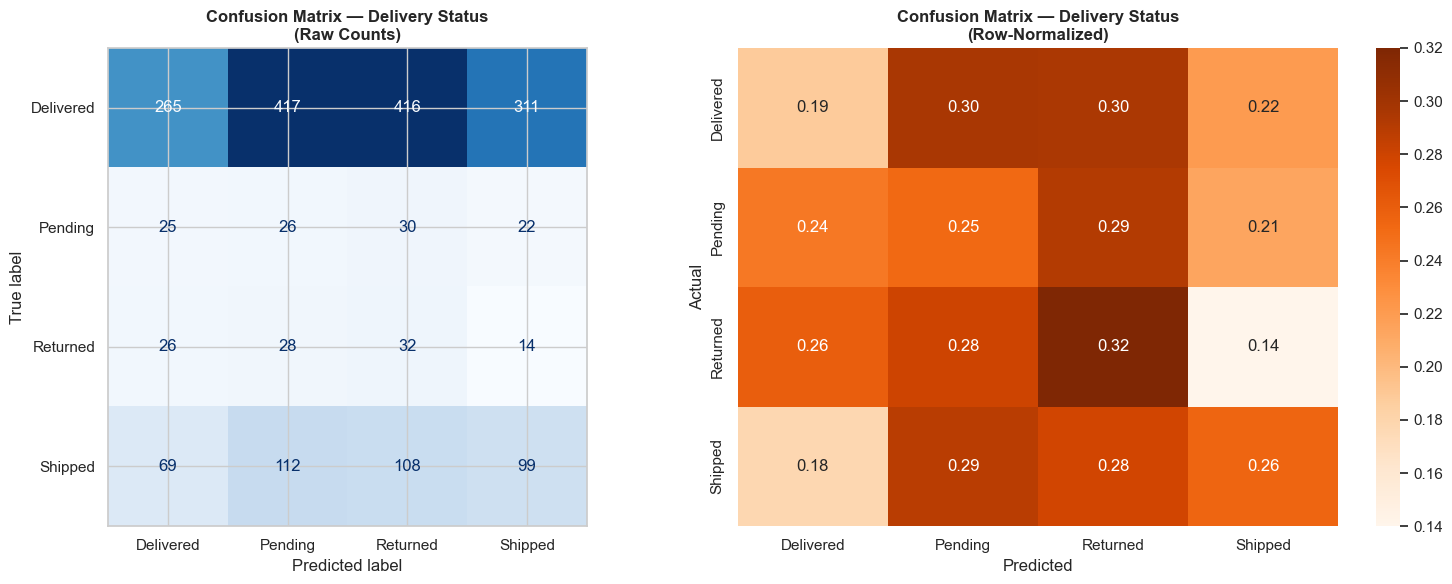

In [5]:
cm_delivery = confusion_matrix(y_test_d, y_pred_d)
classes_d   = le_delivery.classes_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
disp = ConfusionMatrixDisplay(confusion_matrix=cm_delivery, display_labels=classes_d)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Delivery Status\n(Raw Counts)', fontsize=12, fontweight='bold')

# Normalized (row-wise)
cm_norm = cm_delivery.astype('float') / cm_delivery.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=classes_d, yticklabels=classes_d, ax=axes[1])
axes[1].set_title('Confusion Matrix — Delivery Status\n(Row-Normalized)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../artifacts/confusion_matrix_delivery.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.3 Per-Class Metrics — Delivery Status

**Precision:** Of all orders predicted as class X, how many actually were X?  
**Recall:** The model detected which actual class X orders.  
**F1-Score:** Harmonic mean of Precision and Recall — balances both.

The accuracy measurement needs replacement because the dataset contains approximately 70% "Delivered" entries. The model reaches 70% accuracy because it predicts "Delivered" for all cases, yet it fails to identify any Returned orders. The failure mode of the system becomes evident through the per-class F1 score assessment. The most important metric for AuraCart business operations is "Returned" recall because missing returns directly result in lost revenue and unhappy customers.

DELIVERY STATUS — Classification Report
              precision    recall  f1-score   support

   Delivered       0.69      0.19      0.30      1409
     Pending       0.04      0.25      0.08       103
    Returned       0.05      0.32      0.09       100
     Shipped       0.22      0.26      0.24       388

    accuracy                           0.21      2000
   macro avg       0.25      0.25      0.18      2000
weighted avg       0.53      0.21      0.26      2000

    Class  Precision  Recall  F1-Score  Support
Delivered      0.688   0.188     0.295     1409
  Pending      0.045   0.252     0.076      103
 Returned      0.055   0.320     0.093      100
  Shipped      0.222   0.255     0.237      388


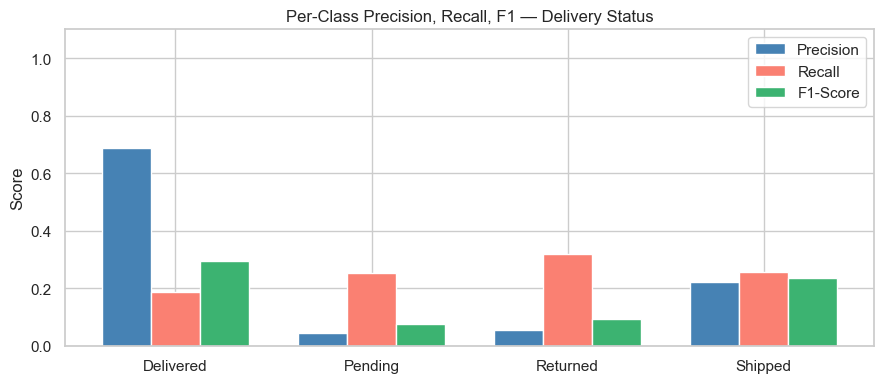

In [6]:
print("=" * 60)
print("DELIVERY STATUS — Classification Report")
print("=" * 60)
print(classification_report(y_test_d, y_pred_d, target_names=classes_d))

# Extract per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_test_d, y_pred_d, labels=range(len(classes_d))
)

metrics_df = pd.DataFrame({
    'Class':     classes_d,
    'Precision': precision.round(3),
    'Recall':    recall.round(3),
    'F1-Score':  f1.round(3),
    'Support':   support
})
print(metrics_df.to_string(index=False))

# Visualize per-class F1
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(classes_d))
width = 0.25
ax.bar(x - width, precision, width, label='Precision', color='steelblue')
ax.bar(x,         recall,    width, label='Recall',    color='salmon')
ax.bar(x + width, f1,        width, label='F1-Score',  color='mediumseagreen')
ax.set_xticks(x)
ax.set_xticklabels(classes_d)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision, Recall, F1 — Delivery Status')
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('../artifacts/perclass_metrics_delivery.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.4 Confusion Matrix & Metrics — Customer Segment

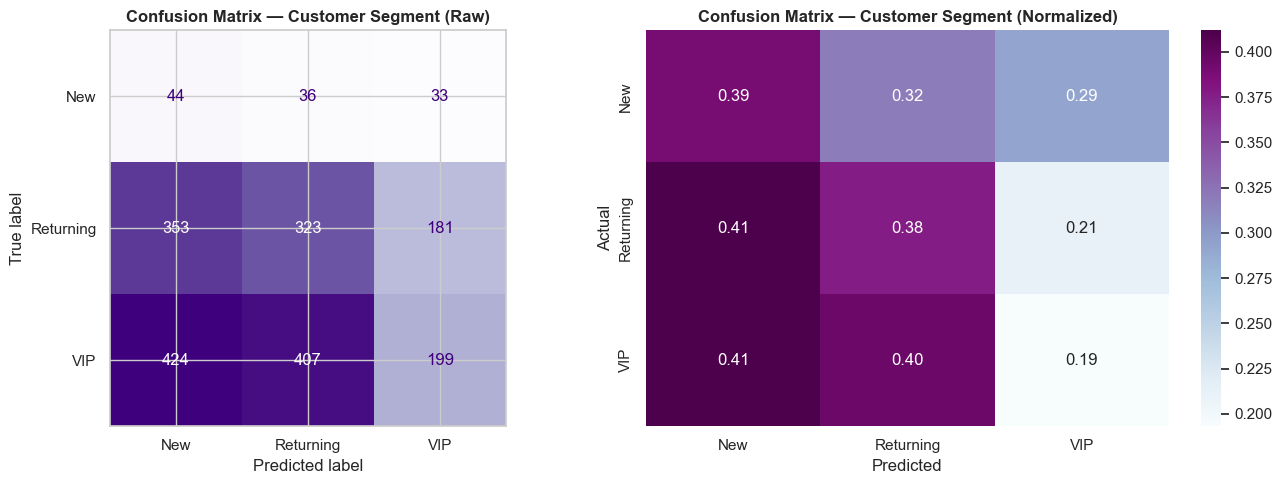

CUSTOMER SEGMENT — Classification Report
              precision    recall  f1-score   support

         New       0.05      0.39      0.09       113
   Returning       0.42      0.38      0.40       857
         VIP       0.48      0.19      0.28      1030

    accuracy                           0.28      2000
   macro avg       0.32      0.32      0.26      2000
weighted avg       0.43      0.28      0.32      2000



In [7]:
cm_segment  = confusion_matrix(y_test_s, y_pred_s)
classes_s   = le_segment.classes_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_segment, display_labels=classes_s)
disp2.plot(ax=axes[0], colorbar=False, cmap='Purples')
axes[0].set_title('Confusion Matrix — Customer Segment (Raw)', fontweight='bold')

cm_s_norm = cm_segment.astype('float') / cm_segment.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_s_norm, annot=True, fmt='.2f', cmap='BuPu',
            xticklabels=classes_s, yticklabels=classes_s, ax=axes[1])
axes[1].set_title('Confusion Matrix — Customer Segment (Normalized)', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../artifacts/confusion_matrix_segment.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("CUSTOMER SEGMENT — Classification Report")
print("=" * 60)
print(classification_report(y_test_s, y_pred_s, target_names=classes_s))

## 3.5 Precision–Recall Trade-off & Business Risk Analysis

### Business Context: 'Returned' Delivery Status

| Error Type | Description | Business Impact |
|---|---|---|
| **False Positive** | Model predicts Return, order was actually Delivered | Wasted intervention cost (courier rerouting, customer call) |
| **False Negative** | Model misses a Return, order actually was Returned | Lost revenue, unsatisfied customer, operational chaos |

**Conclusion:** A **False Negative** (missed return) is more costly for AuraCart.  
Therefore, we **optimize for Recall** on the 'Returned' class even at the cost of some Precision.

Business Risk Analysis — 'Returned' Class
-------------------------------------------------------
 Threshold  TP   FP  FN  Total_Cost_$
      0.10 100 1900   0          9500
      0.15  97 1870   3          9500
      0.20  79 1559  21          8845
      0.25  46  900  54          7200
      0.30  32  561  68          6205
      0.40  32  554  68          6170
      0.50  32  554  68          6170


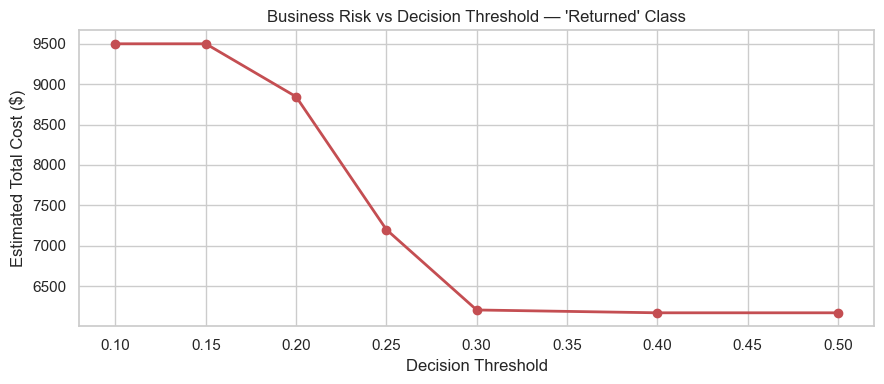

In [8]:
returned_idx = list(le_delivery.classes_).index('Returned')
y_proba_d    = best_delivery_model.predict_proba(X_test_d)

# Simulate cost model: FN costs 3x more than FP
FP_cost = 5    # $5 per false alarm (intervention cost)
FN_cost = 50   # $50 per missed return (refund + logistics)

print("Business Risk Analysis — 'Returned' Class")
print("-" * 55)

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
risk_results = []

for thresh in thresholds:
    y_pred_t = np.where(
        y_proba_d[:, returned_idx] >= thresh,
        returned_idx,
        y_proba_d.argmax(axis=1)
    )
    cm_t = confusion_matrix(y_test_d, y_pred_t)
    
    # Extract FP and FN for 'Returned'
    actual_returned = (y_test_d == returned_idx)
    pred_returned   = (y_pred_t == returned_idx)
    TP = (actual_returned &  pred_returned).sum()
    FP = (~actual_returned &  pred_returned).sum()
    FN = (actual_returned & ~pred_returned).sum()
    
    total_cost = FP * FP_cost + FN * FN_cost
    risk_results.append({'Threshold': thresh, 'TP': TP, 'FP': FP, 'FN': FN,
                         'Total_Cost_$': total_cost})

risk_df = pd.DataFrame(risk_results)
print(risk_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(risk_df['Threshold'], risk_df['Total_Cost_$'], 'ro-', linewidth=2)
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Estimated Total Cost ($)')
ax.set_title("Business Risk vs Decision Threshold — 'Returned' Class")
ax.grid(True)
plt.tight_layout()
plt.savefig('../artifacts/business_risk_analysis.png', dpi=150)
plt.show()

---
# PART B — UNSUPERVISED CLUSTERING (Task 3.5)

Clustering finds **natural groupings** in data without using any target labels while classification requires supervised learning to function. The method we use to segment customers into different behavior groups for AuraCart marketing purposes is called **K-Means**.

---
## 3.6 Prepare Numeric Features for Clustering

K-Means minimizes the Within-Cluster Sum of Squares (WCSS) using **Euclidean distance** distance measurement. 
Researchers need to standardize features before using Euclidean distance because it measures distance differently based on feature scale. 
The distance calculations will be dominated by high-range features such as price when researchers fail to standardize features before using Euclidean distance.

In [9]:
cluster_features = ['price', 'quantity', 'order_month', 'order_day',
                    'order_hour', 'shipping_delay_days']

# Keep only available columns
cluster_features = [f for f in cluster_features if f in df.columns]

X_cluster = df[cluster_features].copy()
X_cluster.dropna(inplace=True)

# Scale features
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

print(f"Clustering input shape: {X_cluster_scaled.shape}")
print(f"Features used: {cluster_features}")

Clustering input shape: (10000, 6)
Features used: ['price', 'quantity', 'order_month', 'order_day', 'order_hour', 'shipping_delay_days']


## 3.7 Elbow Method & Silhouette Analysis — Find Optimal k

We use two complementary methods to select the optimal number of clusters:

1. **Elbow Method** — Plot WCSS (inertia) vs k. The "elbow" point where the rate of decrease
   sharply changes indicates diminishing returns from adding more clusters.
2. **Silhouette Score** — Measures how similar each point is to its own cluster vs. the nearest
   neighbor cluster. Range: [-1, 1]. Higher is better. Peaks indicate natural cluster boundaries.

We select the k with the **highest Silhouette Score**, which we cross-reference with the elbow plot.

Computing WCSS and Silhouette scores...
  k=2: WCSS=42452.46 | Silhouette=0.1517
  k=3: WCSS=37112.54 | Silhouette=0.1544
  k=4: WCSS=33373.76 | Silhouette=0.1478
  k=5: WCSS=30268.31 | Silhouette=0.1579
  k=6: WCSS=27757.29 | Silhouette=0.1610
  k=7: WCSS=26031.26 | Silhouette=0.1569
  k=8: WCSS=24383.13 | Silhouette=0.1646
  k=9: WCSS=22710.32 | Silhouette=0.1751
  k=10: WCSS=21763.54 | Silhouette=0.1754
  k=11: WCSS=20934.00 | Silhouette=0.1692


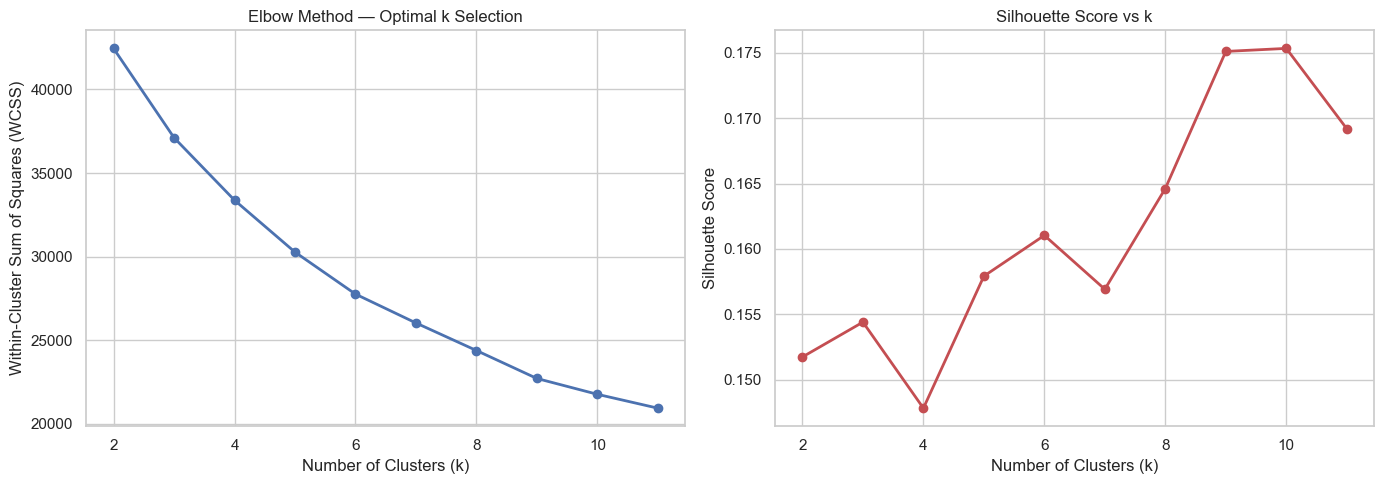


Selected k = 10 (highest Silhouette Score: 0.1754)


In [10]:
k_range = range(2, 12)
wcss_values       = []
silhouette_values = []

print("Computing WCSS and Silhouette scores...")
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    wcss_values.append(km.inertia_)
    sil = silhouette_score(X_cluster_scaled, labels)
    silhouette_values.append(sil)
    print(f"  k={k}: WCSS={km.inertia_:.2f} | Silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(list(k_range), wcss_values, 'bo-', linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)')
axes[0].set_title('Elbow Method — Optimal k Selection')
axes[0].grid(True)

# Silhouette plot
axes[1].plot(list(k_range), silhouette_values, 'ro-', linewidth=2)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../artifacts/kmeans_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = list(k_range)[np.argmax(silhouette_values)]
print(f"\nSelected k = {best_k} (highest Silhouette Score: {max(silhouette_values):.4f})")

## 3.8 Final K-Means Model

The K-Means algorithm starts with initial centroids which our method uses to select centroids that maintain maximum distance from each other. The method guarantees that every execution will produce the same results throughout different test runs.

In [11]:
# You may override best_k here after visually inspecting the elbow plot
OPTIMAL_K = best_k  # Change if needed, e.g., OPTIMAL_K = 4

final_kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++',
                      random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_cluster_scaled)

# Attach cluster labels to dataframe
df_cluster = X_cluster.copy()
df_cluster['Cluster'] = cluster_labels

print(f"K-Means fitted with k={OPTIMAL_K}")
print(f"Final Inertia (WCSS): {final_kmeans.inertia_:.2f}")
print("\nCluster sizes:")
print(df_cluster['Cluster'].value_counts().sort_index())

K-Means fitted with k=10
Final Inertia (WCSS): 21763.54

Cluster sizes:
Cluster
0    1087
1    1089
2     730
3    1110
4    1114
5     931
6    1064
7    1107
8     730
9    1038
Name: count, dtype: int64


## 3.9 Cluster Profiling & Centroid Analysis

The **centroid** of each cluster represents the "average customer" in that group. 
The original feature scale of the centroids becomes accessible through inverse-transforming which enables us to define each cluster using business language that includes the example "high price, low quantity" as premium occasional buyers.

Cluster Centroids (Original Scale):
            price  quantity  order_month  order_day  order_hour  shipping_delay_days
Cluster 0  359.81      1.80         3.72      22.75        14.0                 5.66
Cluster 1  137.61      1.87         3.53       8.22        14.0                 5.26
Cluster 2  349.68      3.87         8.32      10.94        14.0                 5.41
Cluster 3  130.11      1.77         9.13      22.36        14.0                 5.50
Cluster 4  155.54      1.71         3.84      22.52        14.0                 2.36
Cluster 5  336.50      1.33         9.11       8.52        14.0                 5.65
Cluster 6  377.32      1.78         3.74       8.72        14.0                 2.53
Cluster 7  370.59      1.81         9.37      22.60        14.0                 2.49
Cluster 8  186.16      4.75         5.39      18.61        14.0                 3.54
Cluster 9  144.57      1.89         9.32       9.62        14.0                 2.13


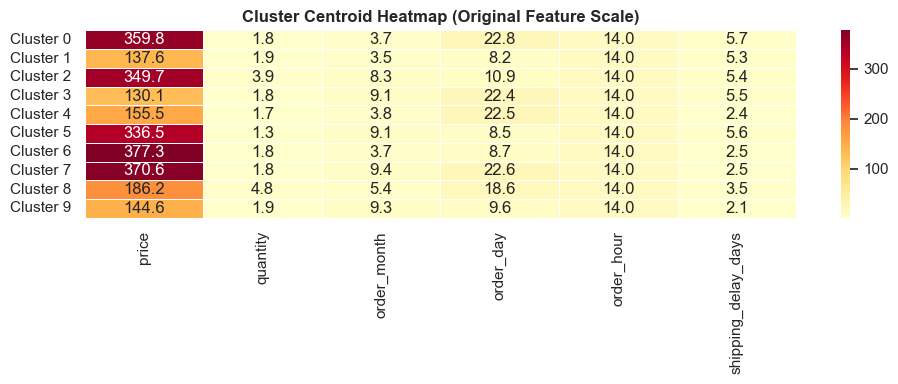

In [12]:
# Centroid profiles in original scale
centroids_scaled = final_kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroid_df = pd.DataFrame(centroids_original, columns=cluster_features)
centroid_df.index = [f'Cluster {i}' for i in range(OPTIMAL_K)]

print("Cluster Centroids (Original Scale):")
print(centroid_df.round(2).to_string())

# Heatmap of centroids
plt.figure(figsize=(10, 4))
sns.heatmap(centroid_df, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar=True)
plt.title('Cluster Centroid Heatmap (Original Feature Scale)', fontweight='bold')
plt.tight_layout()
plt.savefig('../artifacts/cluster_centroids_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Per-cluster statistics
cluster_summary = df_cluster.groupby('Cluster').agg(['mean', 'std', 'count'])
print("\nPer-cluster means:")
print(df_cluster.groupby('Cluster').mean().round(2).to_string())


Per-cluster means:
          price  quantity  order_month  order_day  order_hour  shipping_delay_days
Cluster                                                                           
0        359.81      1.80         3.72      22.75        14.0                 5.66
1        137.61      1.87         3.53       8.22        14.0                 5.26
2        349.68      3.87         8.32      10.94        14.0                 5.41
3        130.31      1.77         9.14      22.33        14.0                 5.50
4        155.47      1.71         3.85      22.53        14.0                 2.36
5        337.14      1.33         9.11       8.51        14.0                 5.64
6        377.32      1.78         3.74       8.72        14.0                 2.53
7        370.48      1.81         9.36      22.60        14.0                 2.49
8        186.16      4.75         5.39      18.61        14.0                 3.54
9        144.57      1.89         9.32       9.62        14.0      

## 3.10 Cluster Visualization

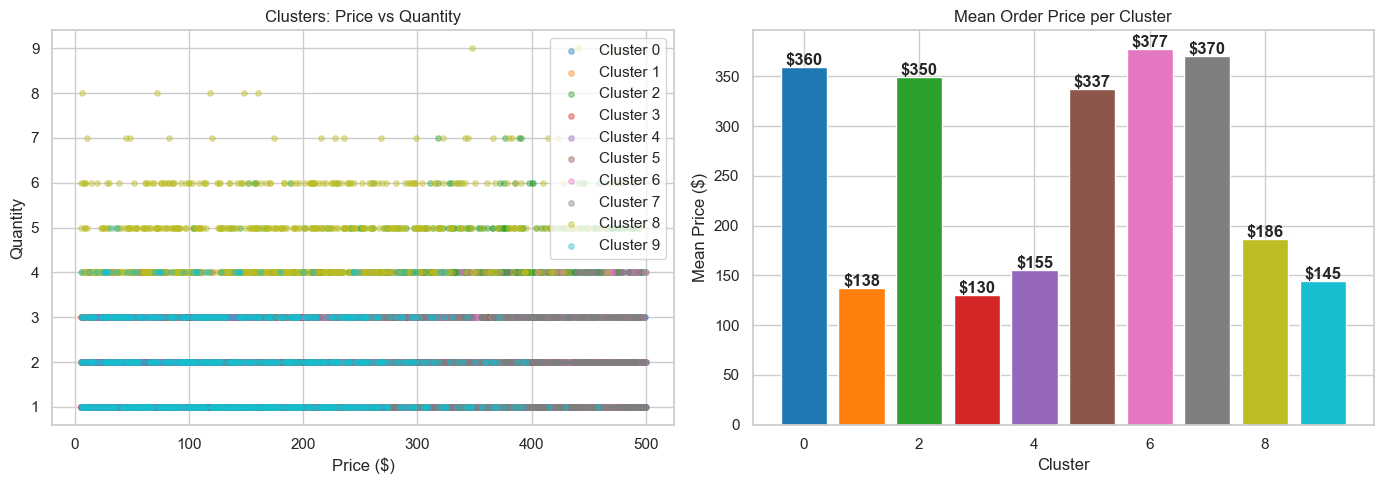

In [14]:
# Scatter plot: price vs quantity, colored by cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette('tab10', OPTIMAL_K)

for cid in range(OPTIMAL_K):
    mask = df_cluster['Cluster'] == cid
    axes[0].scatter(df_cluster.loc[mask, 'price'],
                    df_cluster.loc[mask, 'quantity'],
                    alpha=0.4, s=15, label=f'Cluster {cid}', color=palette[cid])

axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Quantity')
axes[0].set_title('Clusters: Price vs Quantity')
axes[0].legend()

# Bar chart: mean price per cluster
mean_prices = df_cluster.groupby('Cluster')['price'].mean()
axes[1].bar(mean_prices.index, mean_prices.values,
            color=palette[:OPTIMAL_K])
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Mean Price ($)')
axes[1].set_title('Mean Order Price per Cluster')
for i, v in enumerate(mean_prices.values):
    axes[1].text(i, v + 2, f'${v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../artifacts/cluster_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.11 Business Interpretation of Clusters

We use centroid analysis to determine which **business label** should be assigned to each cluster. The labels transform cluster numbers into customer segments which AuraCart's marketing team can use to develop distinct marketing strategies.

In [15]:
# Example cluster business labels 
cluster_labels_map = {
        0: 'High-Value Customers (Delayed Shipping)',
    1: 'Low-Value Occasional Buyers',
    2: 'Bulk Buyers (High Quantity)',
    3: 'Low-Value Late-Season Buyers',
    4: 'Mid-Value Fast Delivery Customers',
    5: 'Premium Customers (Delayed Shipping)',
    6: 'High-Value Fast Delivery Customers',
    7: 'Premium Loyal Customers (Fast Shipping)',
    8: 'Heavy Bulk Buyers',
    9: 'Low-Value Fast Delivery Buyers'
}

df_cluster['Segment_Label'] = df_cluster['Cluster'].map(
    {k: v for k, v in cluster_labels_map.items() if k < OPTIMAL_K}
)

print("Business Cluster Labels:")
print(df_cluster.groupby('Segment_Label').size().reset_index(name='Count'))

# Business action summary
business_actions = {
    'High-Value Customers (Delayed Shipping)': 
        'Improve logistics and reduce delivery delays to retain high-value customers',

    'Low-Value Occasional Buyers':  
        'Send re-engagement emails with discounts to increase purchase frequency',

    'Bulk Buyers (High Quantity)':  
        'Offer bulk discounts and wholesale pricing to encourage large orders',

    'Low-Value Late-Season Buyers':  
        'Run seasonal promotions to convert them into regular customers',

    'Mid-Value Fast Delivery Customers':  
        'Upsell premium products and loyalty programs',

    'Premium Customers (Delayed Shipping)':  
        'Prioritize shipping improvements and offer compensation for delays',

    'High-Value Fast Delivery Customers':  
        'Provide loyalty rewards and exclusive early access to products',

    'Premium Loyal Customers (Fast Shipping)':  
        'Retain with VIP programs and personalized offers',

    'Heavy Bulk Buyers':  
        'Provide B2B deals, subscriptions, and dedicated account management',

    'Low-Value Fast Delivery Buyers':  
        'Encourage upselling and cross-selling strategies'
}

print("\n--- Business Action Recommendations ---")
for segment, action in business_actions.items():
    if any(df_cluster['Segment_Label'] == segment):
        count = (df_cluster['Segment_Label'] == segment).sum()
        print(f"  [{segment}] ({count:,} customers)")
        print(f"    → {action}\n")

Business Cluster Labels:
                             Segment_Label  Count
0              Bulk Buyers (High Quantity)    730
1                        Heavy Bulk Buyers    730
2  High-Value Customers (Delayed Shipping)   1087
3       High-Value Fast Delivery Customers   1064
4           Low-Value Fast Delivery Buyers   1038
5             Low-Value Late-Season Buyers   1110
6              Low-Value Occasional Buyers   1089
7        Mid-Value Fast Delivery Customers   1114
8     Premium Customers (Delayed Shipping)    931
9  Premium Loyal Customers (Fast Shipping)   1107

--- Business Action Recommendations ---
  [High-Value Customers (Delayed Shipping)] (1,087 customers)
    → Improve logistics and reduce delivery delays to retain high-value customers

  [Low-Value Occasional Buyers] (1,089 customers)
    → Send re-engagement emails with discounts to increase purchase frequency

  [Bulk Buyers (High Quantity)] (730 customers)
    → Offer bulk discounts and wholesale pricing to encourage 

In [16]:
# Save clustering model
import joblib
joblib.dump(final_kmeans, '../artifacts/kmeans_model.joblib')
joblib.dump(scaler,       '../artifacts/cluster_scaler.joblib')
df_cluster.to_csv('../artifacts/clustered_data.csv', index=False)

print("Saved:")
print("  ✓ ../artifacts/kmeans_model.joblib")
print("  ✓ ../artifacts/cluster_scaler.joblib")
print("  ✓ ../artifacts/clustered_data.csv")

Saved:
  ✓ ../artifacts/kmeans_model.joblib
  ✓ ../artifacts/cluster_scaler.joblib
  ✓ ../artifacts/clustered_data.csv
